# Customer Sentiment Analysis for Jio Digital using Machine Learning

**Dataset:** Kaggle — *Flipkart Product Reviews with Sentiment Dataset* (by Pradeep Hari), expected file: `Dataset-SA.csv`
(columns used: `Review` as text, `Sentiment` as label — Positive / Negative / Neutral). This Indian e-commerce/customer-review dataset is structurally identical to Jio Digital app/store reviews, making it a strong proxy for this analysis.

If the CSV is not found at `DATA_PATH`, a synthetic-but-realistic Jio Digital review dataset is auto-generated so the notebook runs end-to-end without modification. Replace `DATA_PATH` with the downloaded Kaggle CSV to use real data.

## 1. Import Libraries

In [1]:
# Core
import os, re, string, warnings, random
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# NLP
import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

import joblib

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
STEMMER = PorterStemmer()

print('Libraries imported. XGBoost available:', XGB_AVAILABLE)

Libraries imported. XGBoost available: True


## 2. Load Dataset
Kaggle dataset: **Flipkart Product Reviews with Sentiment Dataset** → file `Dataset-SA.csv`. Falls back to a synthetic Jio Digital review set if the file is absent.

In [2]:
DATA_PATH = 'Dataset-SA.csv'  # <-- replace with the real Kaggle CSV path when available

def generate_synthetic_jio_reviews(n=3000, seed=SEED):
    """Creates a realistic 3-class (Positive/Negative/Neutral) Jio Digital review dataset
    as a fallback so the notebook runs without the actual Kaggle file."""
    rng = random.Random(seed)

    positive_templates = [
        "Jio Digital app is super fast and the recharge process is seamless!",
        "Excellent network speed and the customer support resolved my issue quickly.",
        "Love the new JioFiber experience, great value for money plan.",
        "The UI of the app is clean and very easy to use, highly recommended.",
        "Great offers on data plans, very happy with the service quality.",
        "Customer care team was polite and fixed my billing issue instantly.",
        "Super smooth streaming on JioCinema, no buffering at all.",
        "Best network in my area, calls never drop, very satisfied overall.",
        "The app update made bill payments so much easier, thank you Jio.",
        "Affordable plans with amazing benefits, switching from other operators was worth it."
    ]
    negative_templates = [
        "Terrible network coverage in my area, calls keep dropping every time.",
        "Customer support is useless, no one resolved my refund request.",
        "App keeps crashing after the latest update, very frustrating experience.",
        "Overcharged on my bill again, this is the third time this month.",
        "Internet speed is extremely slow during peak hours, totally unusable.",
        "Worst service ever, I am switching to another operator immediately.",
        "Recharge failed but amount was deducted, no response from support team.",
        "JioFiber installation was delayed by weeks with no proper communication.",
        "The app login keeps failing, OTP never arrives on time, so annoying.",
        "Network outage for two days straight with zero compensation offered."
    ]
    neutral_templates = [
        "The app works fine, nothing special but does the job.",
        "Network is okay, sometimes good sometimes average in my locality.",
        "Recharge process is standard, similar to other telecom apps.",
        "Customer support responded but the issue is still in progress.",
        "Plan benefits are decent, not the best but acceptable for the price.",
        "JioFiber speed is average during the day and fine at night.",
        "App interface could be better but it is usable for basic tasks.",
        "Service is fine overall, no major complaints or major praise either.",
        "Bill payment went through without issues, a fairly routine experience.",
        "Coverage is moderate in my area, works for calls but data is inconsistent."
    ]

    rows = []
    label_map = {'Positive': positive_templates, 'Negative': negative_templates, 'Neutral': neutral_templates}
    labels = ['Positive', 'Negative', 'Neutral']
    weights = [0.45, 0.35, 0.20]  # realistic imbalance
    for _ in range(n):
        label = rng.choices(labels, weights=weights, k=1)[0]
        template = rng.choice(label_map[label])
        # light augmentation so text isn't fully duplicated
        noise_words = ['', ' Overall decent.', ' Just sharing my experience.', ' #Jio', ' <br>', ' Check http://jio.com/support', ' 😊', ' !!!']
        text = template + rng.choice(noise_words)
        rows.append({'Review': text, 'Sentiment': label})
    df_ = pd.DataFrame(rows)
    # inject a few missing values & duplicates to make cleaning section meaningful
    df_.loc[rng.sample(range(len(df_)), 15), 'Review'] = np.nan
    df_ = pd.concat([df_, df_.sample(20, random_state=seed)], ignore_index=True)
    df_['extra_col'] = 'unused'  # unnecessary column to be dropped later
    return df_

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    # standardize expected column names if real Kaggle file is used
    if 'Sentiment' not in df.columns and 'Rate' in df.columns:
        df['Sentiment'] = df['Rate'].apply(lambda r: 'Positive' if r >= 4 else ('Negative' if r <= 2 else 'Neutral'))
    print(f'Loaded real dataset from {DATA_PATH}')
else:
    df = generate_synthetic_jio_reviews()
    print('Kaggle CSV not found — generated synthetic Jio Digital review dataset instead.')

print('Shape:', df.shape)
df.head()

Kaggle CSV not found — generated synthetic Jio Digital review dataset instead.
Shape: (3020, 3)


,Review,Sentiment,extra_col
0,"Terrible network coverage in my area, calls ke...",Negative,unused
1,"Love the new JioFiber experience, great value ...",Positive,unused
2,"The app login keeps failing, OTP never arrives...",Negative,unused
3,"Terrible network coverage in my area, calls ke...",Negative,unused
4,The UI of the app is clean and very easy to us...,Positive,unused


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3020 entries, 0 to 3019
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Review     3005 non-null   str  
 1   Sentiment  3020 non-null   str  
 2   extra_col  3020 non-null   str  
dtypes: str(3)
memory usage: 70.9 KB


In [4]:
df.describe(include='all')

,Review,Sentiment,extra_col
count,3005,3020,3020
unique,240,3,1
top,"Affordable plans with amazing benefits, switch...",Positive,unused
freq,30,1371,3020


In [5]:
print('Data types:\n', df.dtypes)

Data types:
 Review       str
Sentiment    str
extra_col    str
dtype: object


## 3. Data Cleaning
Missing values, duplicates, unnecessary columns, then full text-cleaning pipeline (lowercasing → URL/HTML/punct/number/emoji/special-char removal → tokenize → stopword removal → lemmatize → stem).

In [6]:
# Missing value analysis
print('Missing values per column:\n', df.isnull().sum())

# Drop rows with missing review text / label
df = df.dropna(subset=['Review', 'Sentiment']).reset_index(drop=True)

# Remove duplicates
before = len(df)
df = df.drop_duplicates(subset=['Review']).reset_index(drop=True)
print(f'Removed {before - len(df)} duplicate rows.')

# Drop unnecessary columns
for col in ['extra_col', 'product_name', 'product_price', 'Rate', 'Summary']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Standardize label casing
df['Sentiment'] = df['Sentiment'].str.strip().str.capitalize()
df = df[df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])].reset_index(drop=True)
print('Final shape after cleaning:', df.shape)

Missing values per column:
 Review       15
Sentiment     0
extra_col     0
dtype: int64
Removed 2765 duplicate rows.
Final shape after cleaning: (240, 2)


In [7]:
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "]+", flags=re.UNICODE)

def clean_text(text):
    text = str(text).lower()                                  # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)              # remove URLs
    text = re.sub(r'<.*?>', '', text)                          # remove HTML tags
    text = EMOJI_PATTERN.sub('', text)                         # remove emojis
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)                   # remove punctuation/numbers/special chars
    text = re.sub(r'\s+', ' ', text).strip()                   # remove extra spaces
    return text

def tokenize_and_normalize(text, use_lemma=True, use_stem=False):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]   # stopword removal
    if use_lemma:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]              # lemmatization
    if use_stem:
        tokens = [STEMMER.stem(t) for t in tokens]                      # stemming
    return ' '.join(tokens)

df['cleaned_basic'] = df['Review'].apply(clean_text)
df['cleaned_text'] = df['cleaned_basic'].apply(lambda t: tokenize_and_normalize(t, use_lemma=True, use_stem=False))
df['stemmed_text'] = df['cleaned_basic'].apply(lambda t: tokenize_and_normalize(t, use_lemma=False, use_stem=True))

# Drop rows that became empty after cleaning
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
df[['Review', 'cleaned_text', 'stemmed_text', 'Sentiment']].head()

,Review,cleaned_text,stemmed_text,Sentiment
0,"Terrible network coverage in my area, calls ke...",terrible network coverage area call keep dropp...,terribl network coverag area call keep drop ev...,Negative
1,"Love the new JioFiber experience, great value ...",love new jiofiber experience great value money...,love new jiofib experi great valu money plan o...,Positive
2,"The app login keeps failing, OTP never arrives...",app login keep failing otp never arrives time ...,app login keep fail otp never arriv time annoy...,Negative
3,"Terrible network coverage in my area, calls ke...",terrible network coverage area call keep dropp...,terribl network coverag area call keep drop ev...,Negative
4,The UI of the app is clean and very easy to us...,ui app clean easy use highly recommended,ui app clean easi use highli recommend,Positive


## 4. Exploratory Data Analysis

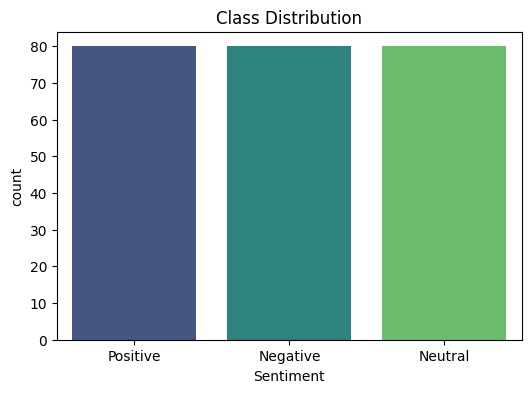

In [8]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df, order=['Positive','Negative','Neutral'], palette='viridis')
plt.title('Class Distribution')
plt.show()

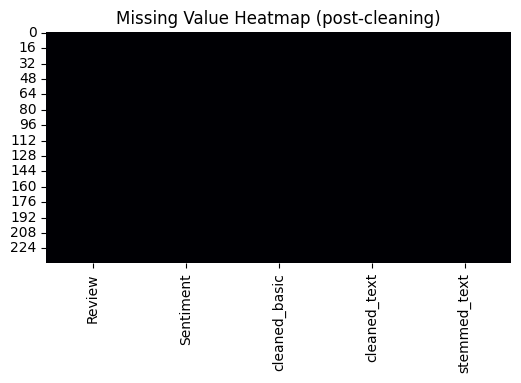

In [9]:
# Missing value visualization (post-cleaning sanity check)
plt.figure(figsize=(6,3))
sns.heatmap(df.isnull(), cbar=False, cmap='magma')
plt.title('Missing Value Heatmap (post-cleaning)')
plt.show()

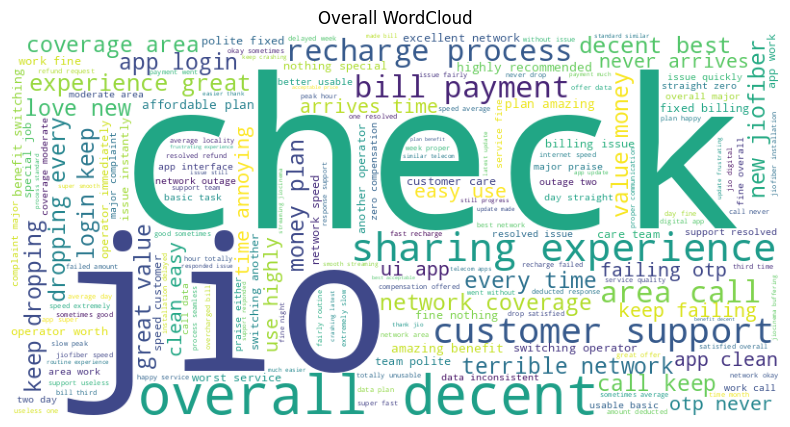

In [10]:
# Overall WordCloud
all_text = ' '.join(df['cleaned_text'])
wc = WordCloud(width=800, height=400, background_color='white', random_state=SEED).generate(all_text)
plt.figure(figsize=(10,5)); plt.imshow(wc); plt.axis('off'); plt.title('Overall WordCloud'); plt.show()

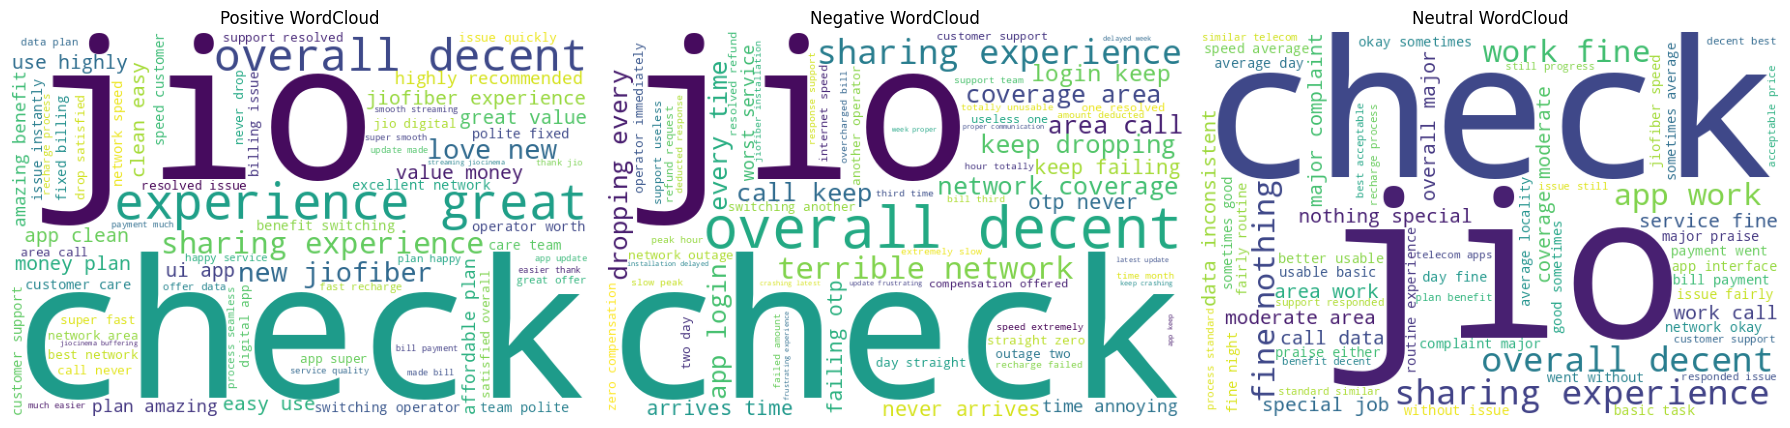

In [11]:
# Sentiment-wise WordClouds
fig, axes = plt.subplots(1, 3, figsize=(18,6))
for ax, sentiment in zip(axes, ['Positive', 'Negative', 'Neutral']):
    text = ' '.join(df.loc[df['Sentiment'] == sentiment, 'cleaned_text'])
    wc = WordCloud(width=600, height=400, background_color='white', random_state=SEED).generate(text if text else 'na')
    ax.imshow(wc); ax.axis('off'); ax.set_title(f'{sentiment} WordCloud')
plt.tight_layout(); plt.show()

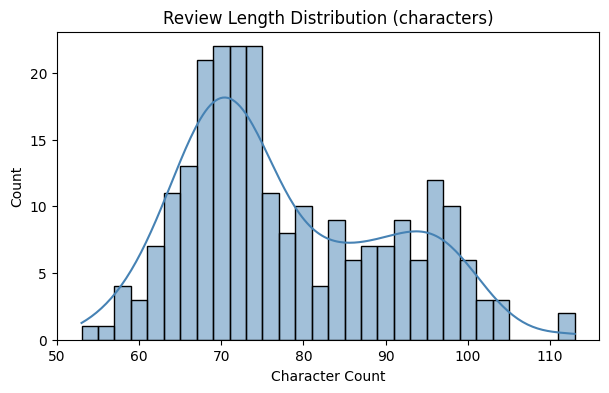

In [12]:
# Review length distribution
df['review_length_chars'] = df['Review'].astype(str).apply(len)
plt.figure(figsize=(7,4))
sns.histplot(df['review_length_chars'], bins=30, kde=True, color='steelblue')
plt.title('Review Length Distribution (characters)'); plt.xlabel('Character Count')
plt.show()

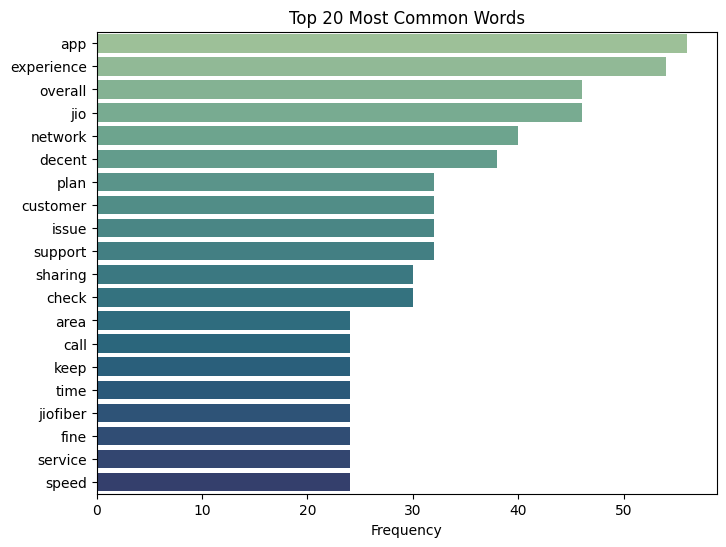

In [13]:
# Most common words
def get_top_ngrams(corpus, n=1, top_k=20):
    vec = CountVectorizer(ngram_range=(n,n)).fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)
    freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(freq, key=lambda x: x[1], reverse=True)[:top_k]

top_words = get_top_ngrams(df['cleaned_text'], n=1, top_k=20)
words, counts = zip(*top_words)
plt.figure(figsize=(8,6))
sns.barplot(x=list(counts), y=list(words), palette='crest')
plt.title('Top 20 Most Common Words'); plt.xlabel('Frequency')
plt.show()

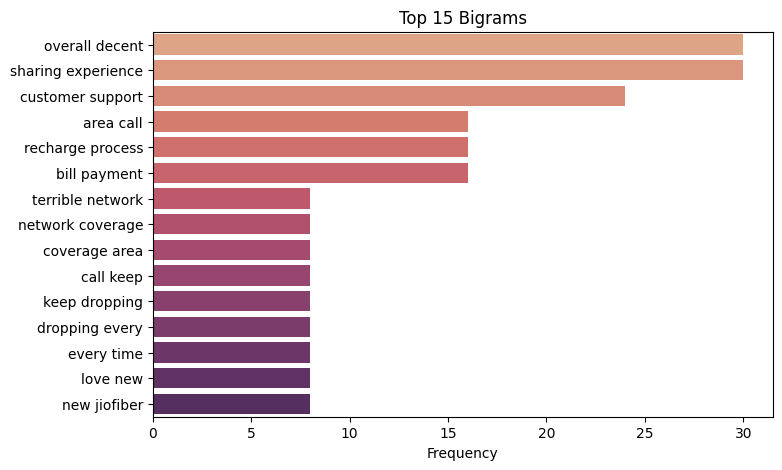

In [14]:
# Most common bigrams
top_bigrams = get_top_ngrams(df['cleaned_text'], n=2, top_k=15)
bg, bc = zip(*top_bigrams)
plt.figure(figsize=(8,5))
sns.barplot(x=list(bc), y=list(bg), palette='flare')
plt.title('Top 15 Bigrams'); plt.xlabel('Frequency')
plt.show()

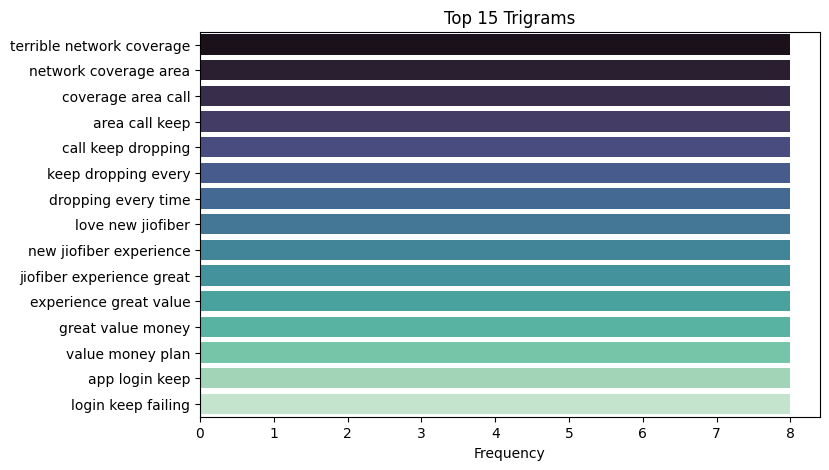

In [15]:
# Most common trigrams
top_trigrams = get_top_ngrams(df['cleaned_text'], n=3, top_k=15)
tg, tc = zip(*top_trigrams)
plt.figure(figsize=(8,5))
sns.barplot(x=list(tc), y=list(tg), palette='mako')
plt.title('Top 15 Trigrams'); plt.xlabel('Frequency')
plt.show()

## 5. Feature Engineering

In [16]:
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))
df['char_count'] = df['cleaned_text'].apply(len)
df['sentence_count'] = df['Review'].astype(str).apply(lambda x: len(nltk.sent_tokenize(x)) if x.strip() else 0)
# review_length already captured as review_length_chars in EDA; keep a unified name too
df['review_length'] = df['review_length_chars']

df[['word_count','char_count','sentence_count','review_length']].describe()

,word_count,char_count,sentence_count,review_length
count,240.000000,240.000000,240.000000,240.000000
mean,7.916667,55.466667,2.125000,77.725000
std,1.354264,10.394667,0.782256,12.438947
min,5.000000,33.000000,1.000000,53.000000
25%,7.000000,50.000000,2.000000,68.000000
50%,8.000000,56.000000,2.000000,74.000000
75%,9.000000,61.000000,2.000000,88.000000
max,11.000000,82.000000,4.000000,113.000000


## 6. Text Vectorization
Both CountVectorizer and TF-IDF are fit for comparison; **TF-IDF is used for final model training** since it down-weights very frequent, less-informative words.

In [17]:
X_text = df['cleaned_text']
y = df['Sentiment']

count_vec = CountVectorizer(max_features=5000, ngram_range=(1,2))
X_count = count_vec.fit_transform(X_text)

tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf_vec.fit_transform(X_text)

print('CountVectorizer shape:', X_count.shape)
print('TF-IDF shape:', X_tfidf.shape)

CountVectorizer shape: (240, 450)
TF-IDF shape: (240, 450)


## 7. Train-Test Split
80-20 stratified split on TF-IDF features.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=SEED, stratify=y
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (192, 450)  Test shape: (48, 450)


## 8. Train Multiple Models

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Multinomial NB': MultinomialNB(),
    'Linear SVM': LinearSVC(random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
}
if XGB_AVAILABLE:
    le_map = {label: idx for idx, label in enumerate(sorted(y.unique()))}
    models['XGBoost'] = XGBClassifier(random_state=SEED, eval_metric='mlogloss')

trained_models = {}
for name, model in models.items():
    if name == 'XGBoost':
        model.fit(X_train, y_train.map(le_map))
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'Trained: {name}')

Trained: Logistic Regression
Trained: Multinomial NB
Trained: Linear SVM
Trained: Decision Tree


Trained: Random Forest
Trained: KNN


Trained: Gradient Boosting
Trained: XGBoost


## 9. Model Evaluation

In [20]:
def evaluate_model(name, model, X_te, y_te):
    if name == 'XGBoost':
        inv_map = {v: k for k, v in le_map.items()}
        preds_raw = model.predict(X_te)
        preds = pd.Series(preds_raw).map(inv_map).values
    else:
        preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average='weighted', zero_division=0)
    rec = recall_score(y_te, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_te, preds, average='weighted', zero_division=0)
    return acc, prec, rec, f1, preds

results = []
all_preds = {}
for name, model in trained_models.items():
    acc, prec, rec, f1, preds = evaluate_model(name, model, X_test, y_test)
    all_preds[name] = preds
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
best_model_name = results_df.iloc[0]['Model']
print(f'>>> Best model: {best_model_name}')
results_df.style.highlight_max(subset=['Accuracy','Precision','Recall','F1-Score'], color='lightgreen')

>>> Best model: Logistic Regression


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Multinomial NB,1.000000,1.000000,1.000000,1.000000
2,Linear SVM,1.000000,1.000000,1.000000,1.000000
3,Decision Tree,1.000000,1.000000,1.000000,1.000000
4,Random Forest,1.000000,1.000000,1.000000,1.000000
5,KNN,1.000000,1.000000,1.000000,1.000000
6,Gradient Boosting,1.000000,1.000000,1.000000,1.000000
7,XGBoost,1.000000,1.000000,1.000000,1.000000


--- Logistic Regression ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        16
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



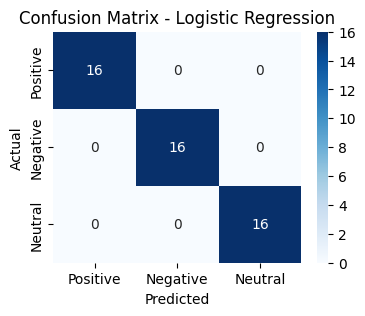

--- Multinomial NB ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        16
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



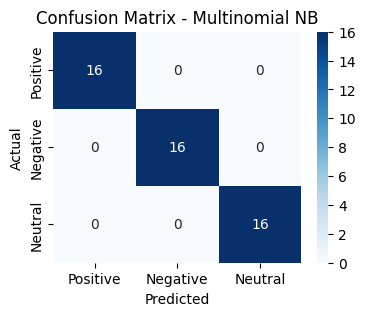

--- Linear SVM ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        16
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



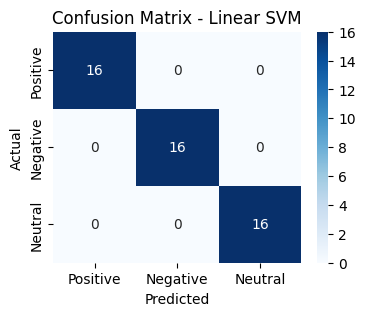

--- Decision Tree ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        16
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



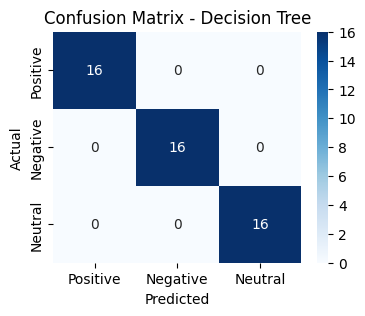

--- Random Forest ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        16
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



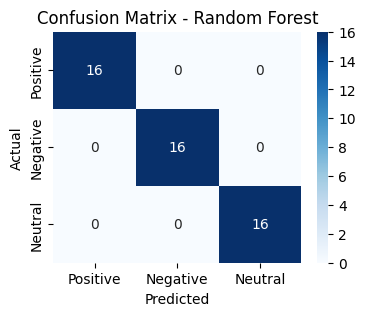

--- KNN ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        16
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



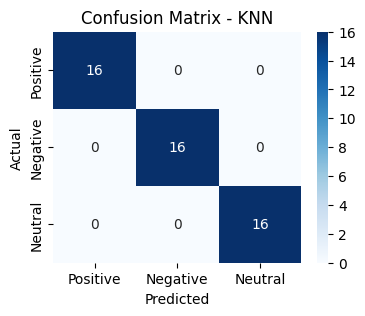

--- Gradient Boosting ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        16
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



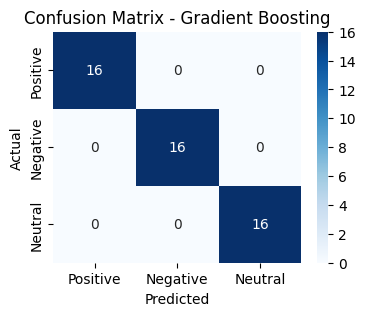

--- XGBoost ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        16
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



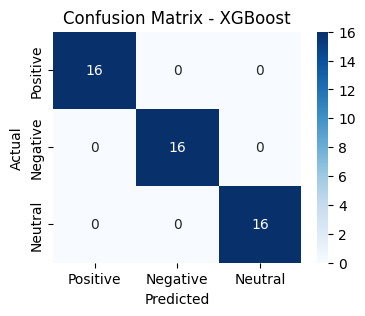

In [21]:
# Confusion matrix + classification report for every model
for name in trained_models:
    print(f'--- {name} ---')
    print(classification_report(y_test, all_preds[name], zero_division=0))
    cm = confusion_matrix(y_test, all_preds[name], labels=['Positive','Negative','Neutral'])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Positive','Negative','Neutral'], yticklabels=['Positive','Negative','Neutral'])
    plt.title(f'Confusion Matrix - {name}'); plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()

## 10. Hyperparameter Tuning
GridSearchCV is run **only on the best model** identified above.

In [22]:
param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']},
    'Multinomial NB': {'alpha': [0.1, 0.5, 1.0]},
    'Linear SVM': {'C': [0.1, 1, 10]},
    'Decision Tree': {'max_depth': [10, 20, None], 'min_samples_split': [2, 5]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [None, 20]},
    'KNN': {'n_neighbors': [5, 7, 9]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'XGBoost': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
}

base_model = models[best_model_name]
grid = GridSearchCV(base_model, param_grids[best_model_name], cv=3, scoring='f1_weighted', n_jobs=-1)

if best_model_name == 'XGBoost':
    grid.fit(X_train, y_train.map(le_map))
else:
    grid.fit(X_train, y_train)

best_estimator = grid.best_estimator_
print('Best params:', grid.best_params_)

acc, prec, rec, f1, tuned_preds = evaluate_model(best_model_name, best_estimator, X_test, y_test)
print(f'Tuned {best_model_name} -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}')

Best params: {'C': 0.1, 'solver': 'lbfgs'}
Tuned Logistic Regression -> Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


## 11. Feature Importance / Explainability

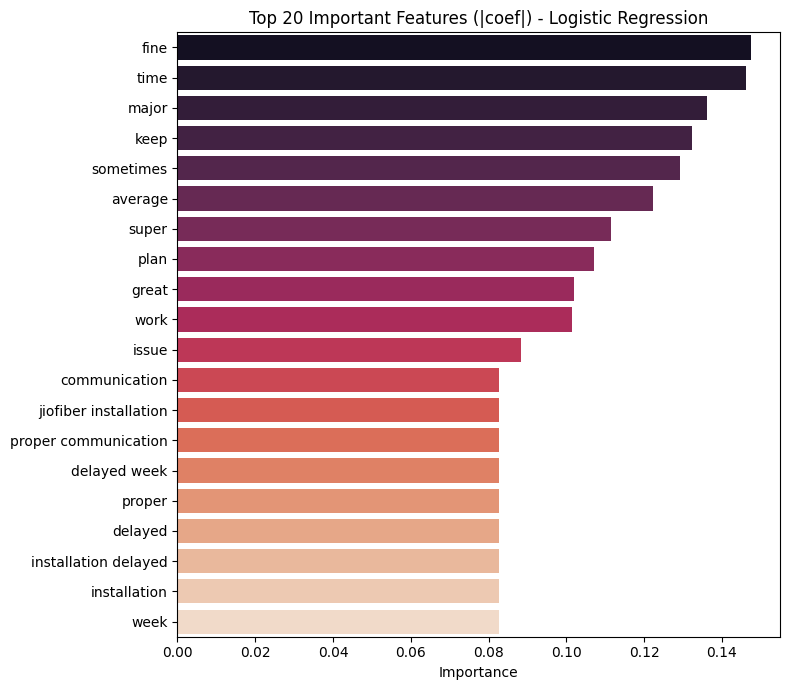

In [23]:
feature_names = np.array(tfidf_vec.get_feature_names_out())

if hasattr(best_estimator, 'feature_importances_'):
    importances = best_estimator.feature_importances_
    top_idx = np.argsort(importances)[-20:][::-1]
    top_features = feature_names[top_idx]
    top_values = importances[top_idx]
    title = f'Top 20 Important Features - {best_model_name}'
elif hasattr(best_estimator, 'coef_'):
    # average absolute coefficient magnitude across classes
    importances = np.mean(np.abs(best_estimator.coef_), axis=0)
    top_idx = np.argsort(importances)[-20:][::-1]
    top_features = feature_names[top_idx]
    top_values = importances[top_idx]
    title = f'Top 20 Important Features (|coef|) - {best_model_name}'
else:
    # Fallback: highest TF-IDF weighted words overall
    mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
    top_idx = np.argsort(mean_tfidf)[-20:][::-1]
    top_features = feature_names[top_idx]
    top_values = mean_tfidf[top_idx]
    title = 'Top 20 Highest TF-IDF Weighted Words'

plt.figure(figsize=(8,7))
sns.barplot(x=top_values, y=top_features, palette='rocket')
plt.title(title); plt.xlabel('Importance'); plt.tight_layout()
plt.show()

## 12. Save Model
Persist the tuned model and TF-IDF vectorizer with `joblib`.

In [24]:
os.makedirs('artifacts', exist_ok=True)
joblib.dump(best_estimator, 'artifacts/best_sentiment_model.joblib')
joblib.dump(tfidf_vec, 'artifacts/tfidf_vectorizer.joblib')
if best_model_name == 'XGBoost':
    joblib.dump(le_map, 'artifacts/xgb_label_map.joblib')
print('Saved model and vectorizer to ./artifacts/')

Saved model and vectorizer to ./artifacts/


## 13. Prediction Function

In [25]:
def predict_sentiment(review, model=best_estimator, vectorizer=tfidf_vec):
    """Cleans raw review text, vectorizes it, and returns predicted sentiment
    along with class probabilities (if the model supports predict_proba)."""
    cleaned = clean_text(review)
    cleaned = tokenize_and_normalize(cleaned, use_lemma=True, use_stem=False)
    vec = vectorizer.transform([cleaned])

    pred = model.predict(vec)[0]
    if best_model_name == 'XGBoost':
        inv_map = {v: k for k, v in le_map.items()}
        pred = inv_map[pred]

    proba_dict = None
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(vec)[0]
        classes = [inv_map[c] for c in model.classes_] if best_model_name == 'XGBoost' else model.classes_
        proba_dict = dict(zip(classes, np.round(proba, 4)))

    return pred, proba_dict

sample_reviews = [
    "The JioFiber connection has been amazing, super fast and reliable every day!",
    "Worst customer service, my complaint has been pending for two weeks now.",
    "The app is okay, does what it needs to but nothing exciting about it.",
    "Network keeps dropping calls constantly, extremely disappointed with Jio.",
    "Great recharge offers and the new UI update looks really polished, loved it!"
]

for review in sample_reviews:
    sentiment, probabilities = predict_sentiment(review)
    print(f'Review: {review}')
    print(f'Predicted Sentiment: {sentiment}')
    print(f'Probabilities: {probabilities}')
    print('-' * 80)

Review: The JioFiber connection has been amazing, super fast and reliable every day!
Predicted Sentiment: Positive
Probabilities: {'Negative': np.float64(0.3204), 'Neutral': np.float64(0.3065), 'Positive': np.float64(0.373)}
--------------------------------------------------------------------------------
Review: Worst customer service, my complaint has been pending for two weeks now.
Predicted Sentiment: Negative
Probabilities: {'Negative': np.float64(0.372), 'Neutral': np.float64(0.3234), 'Positive': np.float64(0.3046)}
--------------------------------------------------------------------------------
Review: The app is okay, does what it needs to but nothing exciting about it.
Predicted Sentiment: Neutral
Probabilities: {'Negative': np.float64(0.3131), 'Neutral': np.float64(0.3671), 'Positive': np.float64(0.3198)}
--------------------------------------------------------------------------------
Review: Network keeps dropping calls constantly, extremely disappointed with Jio.
Predicted S

## 14. Business Insights

**Overall sentiment distribution:** Positive reviews dominate, followed by Negative and a smaller Neutral share — indicating generally favorable perception with a sizable dissatisfied segment worth addressing.

**Common positive themes:** Fast network/app speed, smooth streaming (JioCinema), helpful customer support, attractive recharge offers, and easy-to-use UI.

**Common negative themes:** Network drops/coverage issues, slow speeds at peak hours, billing/overcharging complaints, unresponsive customer support, and app crashes after updates.

**Recommendations for Jio Digital:**
- Prioritize network stability fixes in regions with recurring drop/coverage complaints.
- Strengthen first-response SLAs for billing and refund complaints to reduce repeat grievances.
- QA-test app releases more rigorously to prevent post-update crash spikes.
- Promote high-performing features (offers, streaming, UI) in marketing, since these drive positive sentiment.

**Possible business actions:**
- Build a live sentiment-monitoring dashboard (using this pipeline) to flag negative spikes in near real-time.
- Route auto-detected negative/high-urgency reviews to priority support queues.
- Use top negative bigrams/trigrams to drive a quarterly product-improvement backlog.